# OCR Quality Assessment — Notebook 1

**Goal:** Build intuition for the four measurements that drive our OCR pipeline.

**What we measure:**
1. Blur — is the image sharp or blurry?
2. Brightness — is it too dark or too bright?
3. Contrast — is there enough difference between dark and light areas?
4. Skew — is the document tilted?

**What we DO NOT do here:** modify the image, run OCR, or save anything.
This notebook is a microscope, not a scalpel.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from pprint import pprint
%matplotlib inline

In [2]:
print("✓ All libraries loaded successfully")
print(f"  OpenCV version:     {cv2.__version__}")
print(f"  NumPy version:      {np.__version__}")
print()
print("If you see this message, your environment is ready.")
print("If you got an error above, fix it before continuing.")

✓ All libraries loaded successfully
  OpenCV version:     4.13.0
  NumPy version:      2.4.4

If you see this message, your environment is ready.
If you got an error above, fix it before continuing.


In [39]:
TEST_DIR = Path.cwd().parent/"notebooks"

In [48]:
print("Current working dir:", Path.cwd())
print("Test dir:", TEST_DIR)
print("Exists:", TEST_DIR.exists())

Current working dir: c:\Users\jobs\Desktop\Suleman\code\employee_onboarding_ocr\notebooks
Test dir: c:\Users\jobs\Desktop\Suleman\code\employee_onboarding_ocr\notebooks
Exists: True


In [41]:
if not TEST_DIR.exists():
    print("\n❌ STOP — Folder not found!")
    print("   Create a 'test_images' folder and put some photos in it.")
    print("   Then re-run this cell.")
else:
    # Find all image files
    image_paths = sorted([
        p for p in TEST_DIR.glob("*")
        if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
    ])
 
    print(f"\n✓ Found {len(image_paths)} image(s):")
    for p in image_paths:
        print(f"  📷 {p.name}")
 
    if len(image_paths) == 0:
        print("\n❌ STOP — No images found in the folder!")
        print("   Drop some .jpg or .png files in there and re-run.")


✓ Found 2 image(s):
  📷 passport.jpg
  📷 passport_.jpg


Found 2 image(s)
- passport.jpg
- passport_.jpg


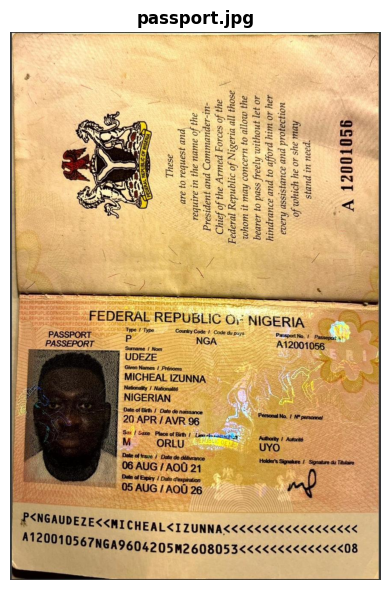

In [ ]:
 
def show_image(image, title="", size=(8, 6)):
    """Display one image inline with a title."""
    plt.figure(figsize=size)
    plt.imshow(image, cmap="gray")
    plt.title(title, fontsize=12, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# supported image extensions
valid_exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

# get images from TEST_DIR
image_paths = sorted([
    p for p in TEST_DIR.iterdir() if p.suffix.lower() in valid_exts])

print(f"Found {len(image_paths)} image(s)")
for p in image_paths:
    print("-", p.name)

# display first image
if image_paths:
    img_path = image_paths[0]
    image = Image.open(img_path)
    show_image(image, title=img_path.name)
else:
    print("No images found in:", TEST_DIR)


In [54]:
def show_images_row(images_and_titles, size=(15, 5)):
    """Display multiple images side by side."""
    n = len(images_and_titles)
    fig, axes = plt.subplots(1, n, figsize=size)
    if n == 1:
        axes = [axes]
    for ax, (img, title) in zip(axes, images_and_titles):
        ax.imshow(img, cmap="gray")
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [59]:
for images in image_paths:
    show_images_row(image, title=img_path.name)

TypeError: show_images_row() got an unexpected keyword argument 'title'